
# Problem 3: Tunneling in the Quartic Double Well

**Problem Statement:**
A particle of mass $m$ moves in a one-dimensional quartic double-well potential described by:
$$V(x)=-\frac{1}{2}\alpha x^2+\beta x^4$$
where $\alpha$ and $\beta$ are positive constants.

**Tasks:**
1. Find the exact Eigenstates 
2. Find the exact energy eigenvalues for the ground state ($E_0$) and the first excited state ($E_1$) using computational methods.
3. Calculate the energy splitting $\Delta E=E_1-E_0$.
4. Determine the tunneling time $\tau\propto\frac{\hbar}{\Delta E}$ for a particle initially localized in the right well to tunnel to the left well.

### Algorithm 
1. Choose the Values of $\alpha \,and\, \beta$ and use the natural units 
2. Define the double well potential $$V(x)=-\frac{\alpha}{2}x^2 + \beta x^4$$
3. Create Uniform Grid of N =1000 points over $x\in[-L,L]$ with spacing dx
4. Building Hamiltonian
   -  Construct the kinetic energy matrix T using the 3-point finite difference approximation for $$-\frac{\hbar^2}{2m}\frac{d^2}{dx^2}$$ (diagonal = $1/dx^2$, off-diagonal = $-0.5/dx^2$)
   - Construc the potetial matrix $V_mat$. as a diagonal matrix with $V(x_i)$ on the diagonal
   - The full *Hamiltonian* $$H = T + V$$
5. Solve the **eigenvalue problem** 
   - Use Lanczos eigensolver i.e. ``eigsh``
   - Use ``eigsh(H, k=10, which='SA')`` to find the 10 lowest energy eigenvalues and eigenstates
6. Normalize the eigenstates 
   - For each state: $$\psi_i\rightarrow \frac{\psi_i}{\sqrt{(\sum|\psi_i|^2 \cdot dx)}}$$
7. Construct localized states
   - From left/right localized wavefunctions: $$\psi_{L,R} = \frac{1}{\sqrt{2}}(\psi_0\pm\psi_1)$$
   - Check the sign overlap on the left half of the grid to assign L and R correctly.
8. Compute the Tunneling parameters
   - Energy Splitting : $\Delta = E_1 - E_0$
   - Tunneling period : $T_{tunnel} = \frac{2 \pi \hbar}{\Delta E} $ 
9.  Time Evolution
   -  Evolve the initial right-localized state: $$\psi(x,t) =\frac{1}{\sqrt2}(e^{-iE_0t}\psi_0+e^{-iE_1t}\psi_1) $$
   -  Track the left and the right well probabilities 
10. Grid Convergence test 
    -  Repeat steps 2-4 for N = 200,400,800, 1600, 3200
    -  Verify that $E_0$ and $\Delta E$ converge (stop changing) as N increases.

#### 1. Physical Problem

We solve:

$$\hat H\psi = E\psi$$

with

$$\hat H = -\frac{\hbar^2}{2m}\frac{d^2}{dx^2}+V(x)$$

and

$$V(x)= -\frac{\alpha}{2}x^2 + \beta x^4$$

This potential creates two wells separated by a barrier.

The particle can tunnel through the barrier even when classical mechanics forbids it.

- **Spatial Grid**
  - a discrete set of regular spaced points, cells, or elements that approximated continuous physical space.
  - Allowing Diff. Equation to be converted into algebric equations that a computer can solve numerically.


In [1]:
# Importing all the important Libraries required for the problem to solve 

import numpy as np 
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import eigsh
# import pandas as pd
import scipy.sparse as sp 


In [2]:
# Physical Parameters (Using the natural units)
h_bar = 1.0
m = 1.0
alpha =10 
beta = 0.5

# Lets create the Spatial GRID for Finite DIfference method
N = 1000 # varrying this is always a good idea
L = 4.0 # Boundaries 
x = np.linspace(-L,L,N)
dx = x[1] - x[0] # computing the grid spacing 

# Lets compute the Potential of the Double well 
V = -0.5*alpha*x**2 + beta*x**4
print("="*50)
print(f"The Value of the Potential is {V}") 

The Value of the Potential is [ 4.80000000e+01  4.72980487e+01  4.66015878e+01  4.59105927e+01
  4.52250390e+01  4.45449020e+01  4.38701575e+01  4.32007810e+01
  4.25367481e+01  4.18780347e+01  4.12246164e+01  4.05764692e+01
  3.99335688e+01  3.92958912e+01  3.86634123e+01  3.80361082e+01
  3.74139550e+01  3.67969287e+01  3.61850055e+01  3.55781616e+01
  3.49763733e+01  3.43796169e+01  3.37878688e+01  3.32011054e+01
  3.26193030e+01  3.20424384e+01  3.14704879e+01  3.09034283e+01
  3.03412361e+01  2.97838881e+01  2.92313610e+01  2.86836317e+01
  2.81406769e+01  2.76024737e+01  2.70689989e+01  2.65402296e+01
  2.60161427e+01  2.54967155e+01  2.49819251e+01  2.44717486e+01
  2.39661633e+01  2.34651466e+01  2.29686757e+01  2.24767280e+01
  2.19892811e+01  2.15063124e+01  2.10277994e+01  2.05537198e+01
  2.00840512e+01  1.96187712e+01  1.91578577e+01  1.87012884e+01
  1.82490411e+01  1.78010939e+01  1.73574245e+01  1.69180110e+01
  1.64828314e+01  1.60518638e+01  1.56250864e+01  1.52024774

- Since we had multiple spatial points therefore the we get the multiple values of $V$ w.r.t. no.of spatial grid.
- And now we plot the potential

<function matplotlib.pyplot.show(close=None, block=None)>

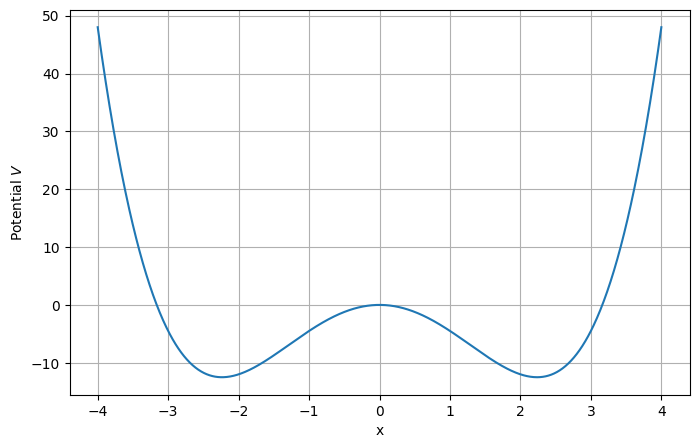

In [3]:
# Plot the given potential first 
plt.figure(figsize=(8,5))
plt.plot(x,V)
plt.xlabel("x")
plt.ylabel("Potential $V$")
plt.grid(True)
plt.show

**Why Finite Difference Method?**
- Computers cannot directly evaluate derivatives.
- We replace the continuous coordinate x by a grid:$$x_1,x_2,x_3,...,x_N$$

and approximate derivatives numerically.

- **Second derivative**:
$$\boxed{\frac{d^2\psi}{dx^2}\approx\frac{\psi_{i+1}-2\psi_i+\psi_{i-1}}{dx^2}}$$

This converts the differential equation into a matrix eigenvalue problem.



The Hamiltonian is $$\hat{H} = \hat{T} + \hat{V}$$ where:
- $\hat{T}$ = Kinetic energy operator
- $\hat{V}$ = Potential energy operator

1. Potential matrix describes the **Landscape**.
   1. Potential Matrix = map of hills and valley
   2. Tries to *localize the particle in either well**.
2. Kinetic Matrix measures **Curvature**.
   1. Straight wave $\rightarrow$ low kinetic energy
   2. Higly curved wave $\rightarrow$ high kinetic energy
   3. couples neighboring points and allows tunneling through the barrier.

---
**Potential Matrix**
- Acts locally : $$\hat{V}\psi(x) = V(x)\psi(x)$$
- So $$V_{ij} = V(x_i)\delta_{ij} $$
- Matrix form: 
$$V=\begin{bmatrix}
V_1 & 0 & 0 & 0 \\
0 & V_2 & 0 & 0\\
0 & 0 & V_3 & 0\\
0 & 0 & 0 & V_4\\
\end{bmatrix}
$$
- Only diagonal entries.
---

**KINETIC Matrix**
- Quantum Mech. defines: $$T=-\frac{\hbar^2}{2m}\frac{d^2}{dx^2} $$

- Using **FDM**:
$$\frac{d^2\psi}{dx^2}\approx \frac{\psi_{i+1}-2\psi_i + \psi_{i-1}}{dx^2}$$
 - Notice:
   - the value at point $i$ depends upon
     - left neighbor
     - itself
     - right neighbor
   - Therefore, Kinetic matrix become tridiagonal.
$$-\frac{d^2}{dx^2}\rightarrow
\frac{1}{dx^2}
\begin{bmatrix}
2 & -1 & 0 & ...\\
-1 & 2 & -1 & ...\\
0 & -1 & 2 & ...
\end{bmatrix}
$$

> This produces a tridiagonal matrix.

**The Off-diagonal entries**$\rightarrow \bf{-1}$ literally means :
> - probability amplitude can hop from one grid point to a neighboring grid point.
> - In condensed matter and quantum computing people also call this term as **hopping amplitude** $$H_{ij}$$ measures the strength of quantum communication between states $i$ and $j$.

**NOTE: Without off-diagonal terms:**
- **No motion possible**
- **No tunneling**
- **No wave behavior**

So, before we reach the double well : $$\boxed{\text{Kinetic Energy = hopping in space}}$$ 

In [4]:
# Lets Build Matrix 
# Kinetic Matrix (Diagonal and off-diagonals)
main_diag = np.full(N, 1/dx**2)
off_diag = np.full(N-1,-0.5/dx**2)
T = diags(
    [off_diag, main_diag, off_diag],
    offsets = [-1,0,1],  # upper diag = +1; main diag =0; and lower diag =-1
    format = 'csr' 
)
print("The Kinetic Matrix is:")
print("="*50)
print(T)

The Kinetic Matrix is:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2998 stored elements and shape (1000, 1000)>
  Coords	Values
  (0, 0)	15593.765625000702
  (0, 1)	-7796.882812500351
  (1, 0)	-7796.882812500351
  (1, 1)	15593.765625000702
  (1, 2)	-7796.882812500351
  (2, 1)	-7796.882812500351
  (2, 2)	15593.765625000702
  (2, 3)	-7796.882812500351
  (3, 2)	-7796.882812500351
  (3, 3)	15593.765625000702
  (3, 4)	-7796.882812500351
  (4, 3)	-7796.882812500351
  (4, 4)	15593.765625000702
  (4, 5)	-7796.882812500351
  (5, 4)	-7796.882812500351
  (5, 5)	15593.765625000702
  (5, 6)	-7796.882812500351
  (6, 5)	-7796.882812500351
  (6, 6)	15593.765625000702
  (6, 7)	-7796.882812500351
  (7, 6)	-7796.882812500351
  (7, 7)	15593.765625000702
  (7, 8)	-7796.882812500351
  (8, 7)	-7796.882812500351
  (8, 8)	15593.765625000702
  :	:
  (991, 991)	15593.765625000702
  (991, 992)	-7796.882812500351
  (992, 991)	-7796.882812500351
  (992, 992)	15593.765625000702
  (992, 993)	-7796.8

- ``format='csr'`` 
  - Compressed Sparse Row 
  - It's a way to store matrices that are mostly zeros w/o wasting the memory.
- Why `diag()`?
  - A $1000 \times 1000$ dense matrix contains one million entries.
  - Most of them are *ZERO*.
  - **Sparse Matrix** stores only NonzeroVlaues, reducing Memory and computation dramatically.

In [5]:
# Now create potential matrix
V_mat = diags(V)
print("The Potential Energy Matrix is ")
print("="*50)
print(V_mat)

The Potential Energy Matrix is 
<DIAgonal sparse matrix of dtype 'float64'
	with 1000 stored elements (1 diagonals) and shape (1000, 1000)>
  Coords	Values
  (0, 0)	48.0
  (1, 1)	47.29804870130593
  (2, 2)	46.60158780605714
  (3, 3)	45.91059273840165
  (4, 4)	45.22503897183644
  (5, 5)	44.544902029207734
  (6, 6)	43.87015748271071
  (7, 7)	43.20078095388975
  (8, 8)	42.53674811363834
  (9, 9)	41.87803468219896
  (10, 10)	41.22461642916332
  (11, 11)	40.57646917347218
  (12, 12)	39.933568783415296
  (13, 13)	39.29589117663174
  (14, 14)	38.6634123201095
  (15, 15)	38.03610823018576
  (16, 16)	37.41395497254679
  (17, 17)	36.796928662227856
  (18, 18)	36.18500546361352
  (19, 19)	35.57816159043726
  (20, 20)	34.97637330578182
  (21, 21)	34.379616922078895
  (22, 22)	33.787868801109326
  (23, 23)	33.20110535400312
  (24, 24)	32.61930304123929
  :	:
  (975, 975)	32.61930304123928
  (976, 976)	33.20110535400309
  (977, 977)	33.78786880110928
  (978, 978)	34.379616922078895
  (979, 979)	34.9

In [6]:
# Lets solve for H = T+V_mat -> this will give me the diagonalized H

H = T + V_mat
np.set_printoptions(
    precision = 6,
    suppress = False,
    linewidth = 150
)

print("The Full Matrix is ")
print("="*50)
print(H)

The Full Matrix is 
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2998 stored elements and shape (1000, 1000)>
  Coords	Values
  (0, 0)	15641.765625000702
  (0, 1)	-7796.882812500351
  (1, 0)	-7796.882812500351
  (1, 1)	15641.063673702009
  (1, 2)	-7796.882812500351
  (2, 1)	-7796.882812500351
  (2, 2)	15640.36721280676
  (2, 3)	-7796.882812500351
  (3, 2)	-7796.882812500351
  (3, 3)	15639.676217739103
  (3, 4)	-7796.882812500351
  (4, 3)	-7796.882812500351
  (4, 4)	15638.990663972538
  (4, 5)	-7796.882812500351
  (5, 4)	-7796.882812500351
  (5, 5)	15638.31052702991
  (5, 6)	-7796.882812500351
  (6, 5)	-7796.882812500351
  (6, 6)	15637.635782483412
  (6, 7)	-7796.882812500351
  (7, 6)	-7796.882812500351
  (7, 7)	15636.966405954592
  (7, 8)	-7796.882812500351
  (8, 7)	-7796.882812500351
  (8, 8)	15636.30237311434
  :	:
  (991, 991)	15636.30237311434
  (991, 992)	-7796.882812500351
  (992, 991)	-7796.882812500351
  (992, 992)	15636.966405954592
  (992, 993)	-7796.88281250

- Lets solve the TISE $$\hat{H}\psi_n = E_n\psi_n$$
- After discretization : $$H\psi_n=E_n\psi_n$$ where 
  - $H$ = Hamiltonian Matrix
  - $\psi_n$ = eigenvector
  - $E_n$ = eigenvalues
- What does ``eigsh()`` do?
  - eig $\rightarrow$ eigenvalue solver
  - sh  $\rightarrow$ symmetric/hermitian matrix
  - Our Hamiltonian satisfies $$H^T=H$$ because:
    - Kinetic matrix is symmetric
    - Potential matrix is diagonal ($\therefore$ symmetric)
- k = n_states is the no. of eigenstates to find for.
- What is ``which = 'SA'``?
  - means smallest Algebraic
  - Return the smallest eigenvalues.


In [7]:
# Now its time to solve the eigen energies
# we only need the lowest states 
n_states = 10

energies, states = eigsh(
    H,
    k = n_states,
    which = 'SA'
)
print("=" * 40)
print("       LOWEST ENERGY EIGENSTATES")
print("=" * 40)

for i, E in enumerate(energies):
    print(f"State {i:2d}  |  Energy = {E:12.6f}")

print("=" * 40)

for i in range(n_states):
    print(f"\nψ_{i}(first 10 points)")
    print(states[:10, i])

       LOWEST ENERGY EIGENSTATES
State  0  |  Energy =   -10.316825
State  1  |  Energy =   -10.316811
State  2  |  Energy =    -6.189931
State  3  |  Energy =    -6.187996
State  4  |  Energy =    -2.566726
State  5  |  Energy =    -2.482772
State  6  |  Energy =     0.031908
State  7  |  Energy =     0.903086
State  8  |  Energy =     2.737224
State  9  |  Energy =     4.550581

ψ_0(first 10 points)
[-1.175628e-06 -2.360049e-06 -3.561909e-06 -4.789772e-06 -6.052177e-06 -7.357695e-06 -8.714984e-06 -1.013284e-05 -1.162025e-05 -1.318643e-05]

ψ_1(first 10 points)
[-1.175646e-06 -2.360085e-06 -3.561963e-06 -4.789845e-06 -6.052269e-06 -7.357806e-06 -8.715116e-06 -1.013299e-05 -1.162043e-05 -1.318663e-05]

ψ_2(first 10 points)
[-4.068589e-06 -8.165456e-06 -1.231834e-05 -1.655463e-05 -2.090154e-05 -2.538628e-05 -3.003621e-05 -3.487899e-05 -3.994272e-05 -4.525607e-05]

ψ_3(first 10 points)
[4.075016e-06 8.178354e-06 1.233779e-05 1.658077e-05 2.093454e-05 2.542635e-05 3.008360e-05 3.493400e-0

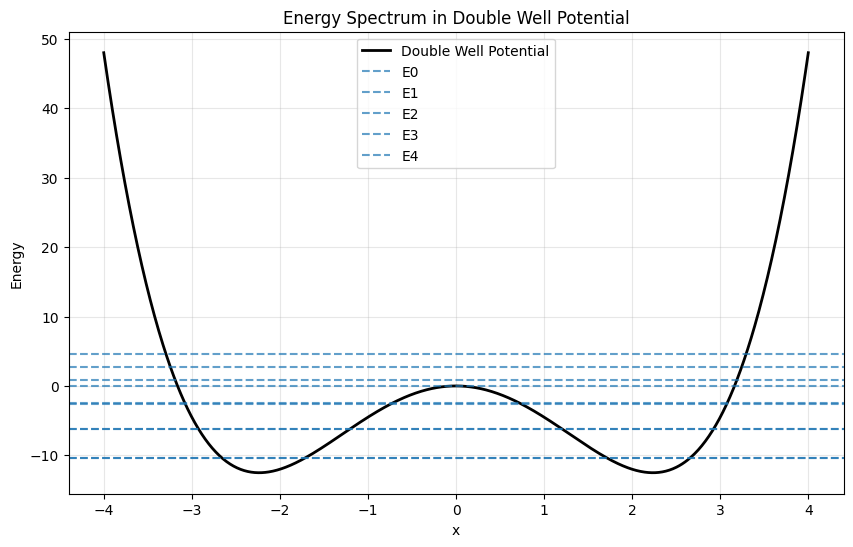

In [8]:
plt.figure(figsize=(10,6))
plt.plot(x, V, 'k', lw=2, label='Double Well Potential')

for i, E in enumerate(energies):
    plt.axhline(E, ls='--', alpha=0.7,
                label=f'E{i}' if i < 5 else None)
plt.xlabel('x')
plt.ylabel('Energy')
plt.title('Energy Spectrum in Double Well Potential')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


- Now Normalize the wavefunction 
- On grid the **continuous probability** is $$\sum_i|\psi_i|^2dx=1 $$

In [9]:
normalized_states = np.zeros_like(states)
for i in range(n_states):
    psi = states[:, i]
    norm = np.sqrt(np.sum(np.abs(psi)**2) * dx)
    normalized_states[:, i] = psi / norm
    
for i in range(10):
    psi = normalized_states[:, i]
    check = np.sum(np.abs(psi)**2) * dx
    print(f"State {i}: {check:.10f}")

State 0: 1.0000000000
State 1: 1.0000000000
State 2: 1.0000000000
State 3: 1.0000000000
State 4: 1.0000000000
State 5: 1.0000000000
State 6: 1.0000000000
State 7: 1.0000000000
State 8: 1.0000000000
State 9: 1.0000000000


/tmp/ipykernel_58124/2185780392.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('Dark2')(np.linspace(0, 1, 8)) # Use dark distinct colors


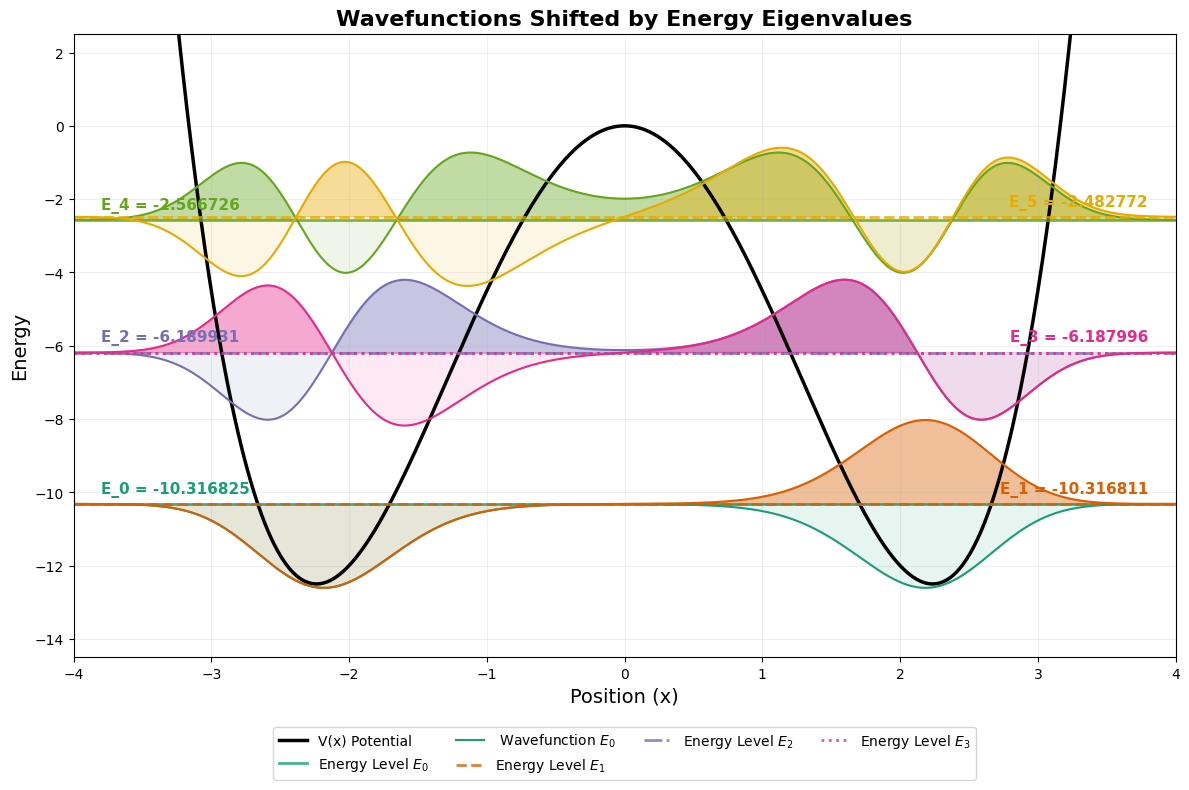

In [10]:
import matplotlib.cm as cm # for color mapping

plt.figure(figsize=(12, 8))

# 1. Plot the black Double Well Potential curve
plt.plot(x, V, 'k', lw=2.5, label='V(x) Potential')

scale = 3.0
colors = cm.get_cmap('Dark2')(np.linspace(0, 1, 8)) # Use dark distinct colors
#defining the linestyle
line_styles = ['-','--','-.',':']

# 2. Plot the first 6 eigenstates on top of their energy levels
for i in range(6):
    E = energies[i]
    psi = normalized_states[:, i]
    c = colors[i]

    # Selecting distinct line for this energy level.
    current_ls = line_styles[i%len(line_styles)]
    # Calculate the shifted wavefunction (Energy baseline + scaled amplitude)
    psi_shifted = E + scale * psi
    
    # Draw a colored dotted baseline for the exact energy level E_n
    plt.axhline(E, ls=current_ls, color=c, lw=2.0, alpha=0.8, label=f'Energy Level $E_{{{i}}}$' if i < 4 else "")
    
    label_text = f'$E_{{{i}}}$'
    
    # Write the energy value on the energy line
    # Alternate sides so they don't overlap if energies are close
    if i % 2 == 0:
        plt.text(-3.8, E + 0.3, f'E_{i} = {E:.6f}', color=c, fontsize=11, fontweight='bold', ha='left')
    else:
        plt.text(3.8, E + 0.3, f'E_{i} = {E:.6f}', color=c, fontsize=11, fontweight='bold', ha='right')
    
    # Plot the wavefunction outline
    plt.plot(x, psi_shifted, lw=1.5, color=c, label=f' Wavefunction $E_{{{i}}}$' if i==0 else "")
    
    # Fill the area under the curve for a beautiful visual effect
    plt.fill_between(x, E, psi_shifted, where=(psi_shifted > E), color=c, alpha=0.4)
    plt.fill_between(x, E, psi_shifted, where=(psi_shifted <= E), color=c, alpha=0.1)

# 3. Formatting the graph
plt.xlabel('Position (x)', fontsize=14)
plt.ylabel('Energy', fontsize=14)
plt.title('Wavefunctions Shifted by Energy Eigenvalues', fontsize=16, fontweight='bold')

plt.xlim(-4, 4)
plt.ylim(min(V) - 2, max(energies[:6]) + 5) 

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4, fancybox=True)
plt.grid(alpha=0.2)
plt.tight_layout()

plt.show()


- For a symmetric double well 
  - Ground State $\psi_0$ is **symmetric(even)**
  - First excited state $\psi_1$ is **anti-symmetric(odd)**
- *Without Tunneling* left well and right well state would have exact **same energy**. So $$\Delta E=0 $$
- *With Tunneling* the degenracy breaks and we get $E_0,E_1,...$
  - The difference $$\Delta E $$ measures the tunneling strength.

- **What is tunneling splitting?**
  - Tunneling splitting is the small energy difference between the symmetric and antisymmetric states produced by quantum tunneling.
  - It is defined as $$\Delta E = E_1-E_0$$
  - It is a direct measure of the strength of tunneling:
    - large $\Delta E$ → strong tunneling,
    - small $\Delta E$ → weak tunneling.

---
Constructing the Localized States 
-  Extract the two lowest states $\psi_0(x)$ and $\psi_1(x)$
-  To obtain right and left localized states $$\psi_L=\frac{1}{\sqrt{2}}(\psi_0+\psi_1) \\\psi_R=\frac{1}{\sqrt{2}}(\psi_0-\psi_1)$$

The Energy spliting is :  1.4915052350517044e-05
The Graphs


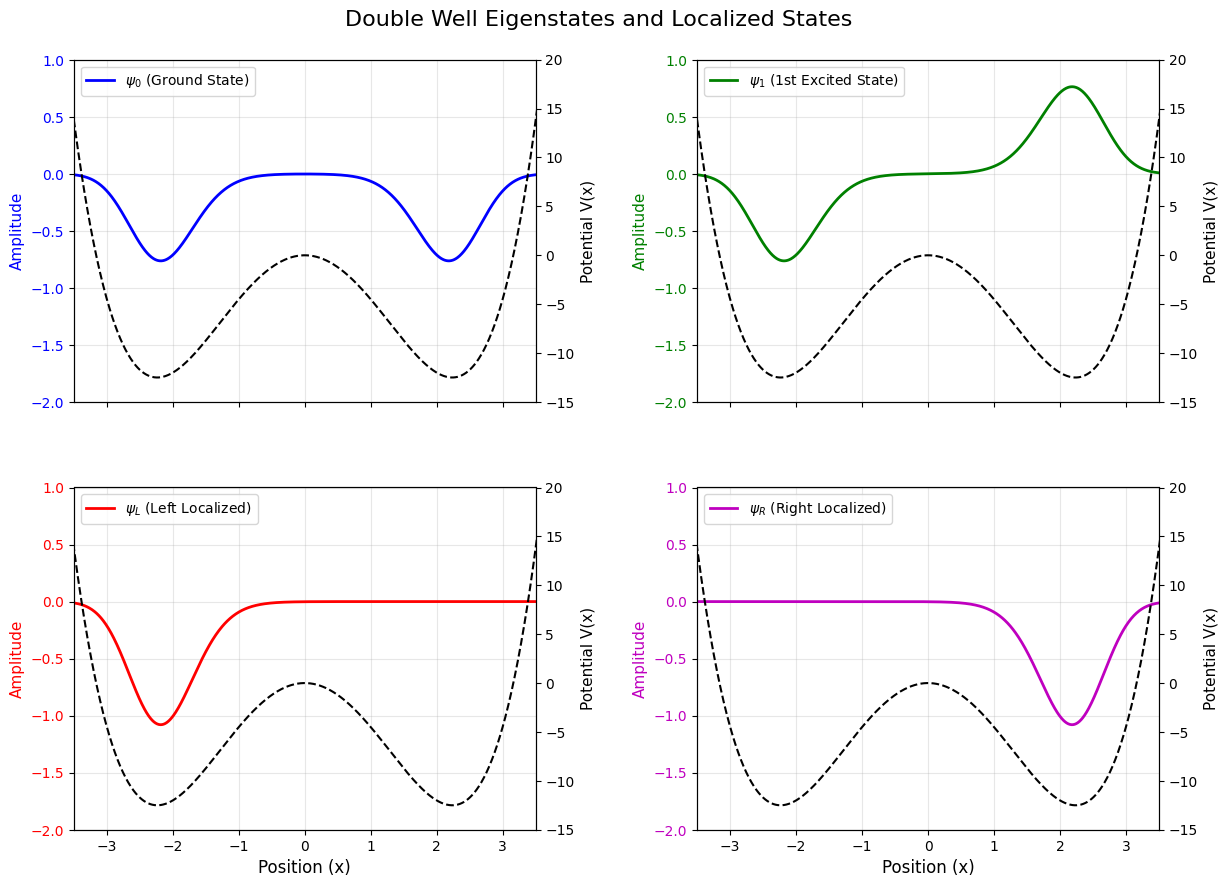

In [11]:
delta_E = energies[1] - energies[0]
print("The Energy spliting is : ",delta_E)
psi0 = normalized_states[:,0]
psi1 = normalized_states[:,1]

# Ensure robust localization regardless of the eigensolver's arbitrary sign for psi1
left_mask = x < 0
if np.sum(psi0[left_mask] * psi1[left_mask]) > 0:
    psi_L = (psi0 + psi1) / np.sqrt(2)
    psi_R = (psi0 - psi1) / np.sqrt(2)
else:
    psi_L = (psi0 - psi1) / np.sqrt(2)
    psi_R = (psi0 + psi1) / np.sqrt(2)

print("="*50)
print("The Graphs")

# Creating a 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
plt.subplots_adjust(hspace=0.25, wspace=0.35)

states = [psi0, psi1, psi_L, psi_R]
labels = [r'$\psi_0$ (Ground State)', r'$\psi_1$ (1st Excited State)', r'$\psi_L$ (Left Localized)', r'$\psi_R$ (Right Localized)']
colors = ['b', 'g', 'r', 'm']

# Flatten the 2x2 axes array so we can loop over it easily
axes_flat = axes.flatten()

for ax, psi, label, color in zip(axes_flat, states, labels, colors):
    # Plot the wavefunction
    ax.plot(x, psi, color=color, linewidth=2, label=label)
    ax.set_ylabel('Amplitude', color=color, fontsize=11)
    ax.tick_params(axis='y', labelcolor=color)
    ax.set_xlim(-3.5, 3.5)
    # Set y-limits roughly to cover amplitude
    ax.set_ylim(-2.0, 1.0)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    
    # Plot the real potential on secondary y-axis
    ax2 = ax.twinx()
    ax2.plot(x, V, 'k--', alpha=1, label='V(x)')
    ax2.set_ylabel('Potential V(x)', color='k', fontsize=11)
    ax2.tick_params(axis='y', labelcolor='k')
    ax2.set_ylim(-15, 20)

# Set x-labels for the bottom row only
axes[1, 0].set_xlabel('Position (x)', fontsize=12)
axes[1, 1].set_xlabel('Position (x)', fontsize=12)

plt.suptitle('Double Well Eigenstates and Localized States', fontsize=16, y=0.93)
plt.show()

- Lets find the Tunneling frequency 
- For $\hbar=1$ : 
  - Angular tuneling frequency $$\omega = \Delta E/\hbar$$ and 
  - Ordinary frequency $$\omega = 2\pi f \\ f_{tunnel}=\frac{\Delta E}{2\pi\hbar} $$
- Tunneling Period 
  - $$f=\frac{1}{T}$$
  - Therefore $$\boxed{T_{tunnel}=\frac{1}{f}=\frac{2\pi\hbar}{\Delta E}}$$

In [12]:
omega = delta_E
f_tunnel = delta_E/(2*np.pi)
T_tunnel = 2*np.pi/delta_E

print(f"The Energy split, ΔE = {delta_E:.8f}")
print(f"ω  = {omega:.8f}")
print(f"f  = {f_tunnel:.8f}")
print(f"T  = {T_tunnel:.8f}")

The Energy split, ΔE = 0.00001492
ω  = 0.00001492
f  = 0.00000237
T  = 421264.71697981


NOW TIME EVOLUTION
- The exact evolution is $$\psi(x,t)=\frac{1}{\sqrt2}(e^{-iE_0t}\psi_0+e^{-iE_1t}\psi_1)$$

In [13]:
# the exact time evolution is 
def psi_t(t):
    return(
        np.exp(-1j*energies[0]*t)*psi0
        +
        np.exp(-1j*energies[1]*t)*psi1
    )/np.sqrt(2)

#for finding the Probability density
def density(t):
    psi = psi_t(t)
    return np.abs(psi)**2

#Left and right well Probability 
left_mask = x < 0 # this will select all grid point with x<0
right_mask = x >=0
# NOTE  Here the time is dimensionless 
def P_left(t):
    rho = density(t)
    return np.sum(rho[left_mask])*dx

def P_right(t):
    rho = density(t)
    return np.sum(rho[right_mask])*dx

# Observing the tunneling
times = np.linspace(0,2*T_tunnel,400)
    # creating empty list to store the probability of finding the particle in the left/right well
PL = []
PR = []
for t in times:
    PL.append(P_left(t))
    PR.append(P_right(t))
import pandas as pd
results =pd.DataFrame({
    "Times": times,
    "Left Probab.": PL,
    "Right Probab.": PR 
})
    #Displa first 10 rows
print(results.head(10))

          Times  Left Probab.  Right Probab.
0      0.000000      1.000000   1.854217e-07
1   2111.602591      0.999752   2.481433e-04
2   4223.205183      0.999008   9.917709e-04
3   6334.807774      0.997770   2.230331e-03
4   8446.410366      0.996037   3.962595e-03
5  10558.012957      0.993813   6.186844e-03
6  12669.615548      0.991099   8.900873e-03
7  14781.218140      0.987898   1.210199e-02
8  16892.820731      0.984213   1.578702e-02
9  19004.423322      0.980048   1.995231e-02


### Understanding Dimensionless Time and Step Size

**1. Natural Units & Dimensionless Time**
- The simulation uses **natural units** where $\hbar = 1$ and $m = 1$.
- To convert the dimensionless time $t_{\text{code}}$ back to physical time (e.g., in seconds), multiply by the characteristic time scale $t_0$:
  $$t_{\text{real}} = t_{\text{code}} \times t_0 \quad \text{where} \quad t_0 = \frac{m L_0^2}{\hbar}$$
  *(with $m$ and $L_0$ in standard physical units)*.

**2. Why is the time step large ($\approx 2111.60$)?**
- The energy splitting $\Delta E$ is extremely small ($\Delta E \approx 0.00001492$), leading to a huge tunneling period: 
  $$T_{\text{tunnel}} = \frac{2\pi}{\Delta E} \approx 421,264.73$$
- The code simulates two full tunneling cycles ($2 \times T_{\text{tunnel}} \approx 842,529.46$) using 400 points (`np.linspace(0, 2*T_tunnel, 400)`).
- This divides the total time into 399 equal intervals, yielding the observed step size:
  $$\Delta t = \frac{2 \times 421,264.73}{399} \approx 2111.60$$
- This large step size is computationally efficient, avoiding millions of unnecessary calculations while accurately capturing the slow tunneling process.

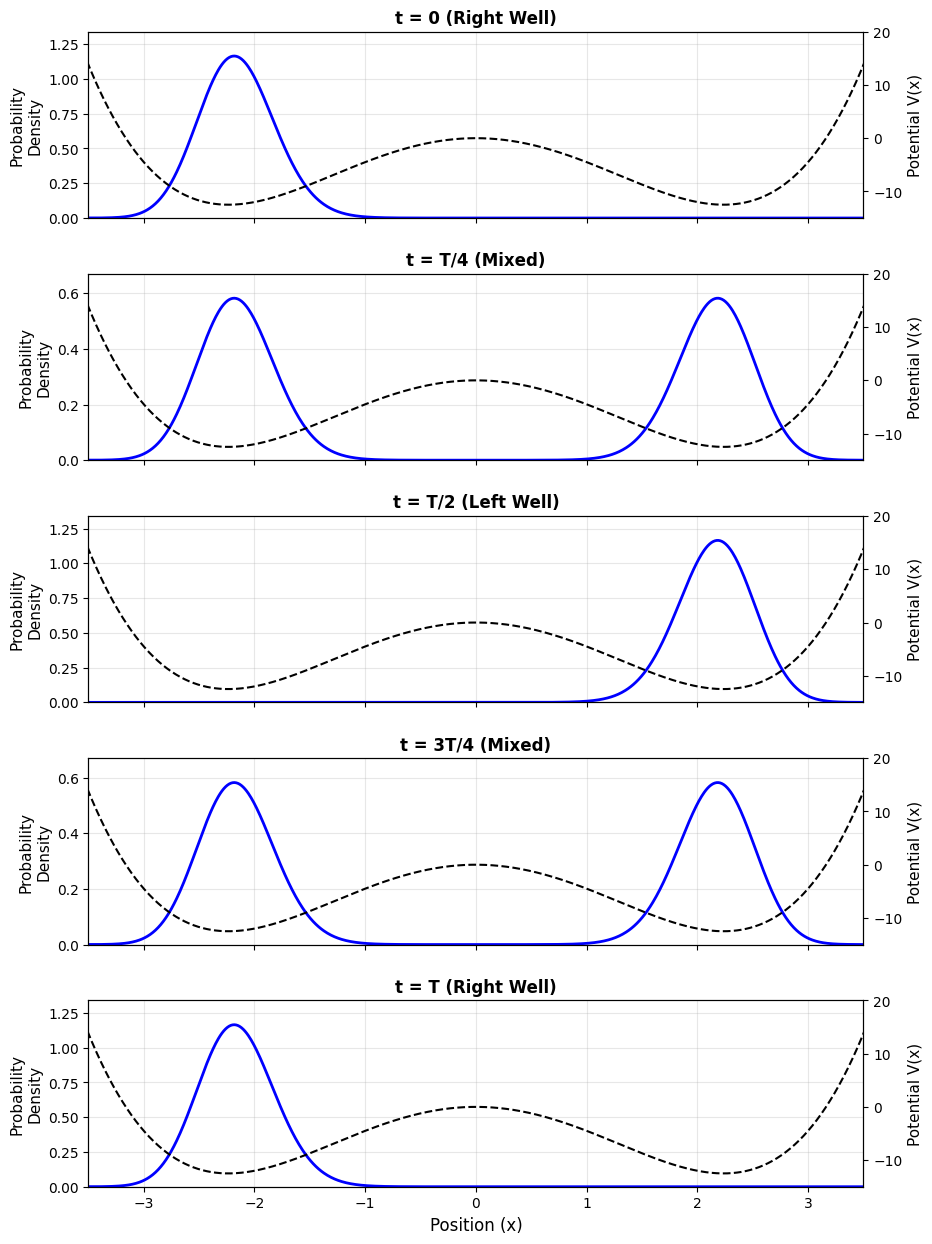

In [14]:
# Choose specific times to plot: 0, T/4, T/2, 3T/4, T
times_to_plot = [0, T_tunnel/4, T_tunnel/2, 3*T_tunnel/4, T_tunnel]
labels = ['t = 0 (Right Well)', 't = T/4 (Mixed)', 't = T/2 (Left Well)', 't = 3T/4 (Mixed)', 't = T (Right Well)']

fig, axes = plt.subplots(5, 1, figsize=(10, 15), sharex=True)
plt.subplots_adjust(hspace=0.3)

for ax, t, label in zip(axes, times_to_plot, labels):
    rho = density(t)
    # Plot the probability density on the primary left y-axis
    ax.plot(x, rho, 'b-', linewidth=2, label='|ψ(x,t)|²')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_ylabel('Probability\nDensity', color='black', fontsize=11)
    ax.tick_params(axis='y')
    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(0, max(rho)*1.15)
    ax.grid(True, alpha=0.3)
    
    # Create a secondary right y-axis for the real potential
    ax2 = ax.twinx()
    ax2.plot(x, V, 'k--', alpha=1, label='V(x)')
    ax2.set_ylabel('Potential V(x)', color='k', fontsize=11)
    ax2.tick_params(axis='y', labelcolor='k')
    # Limit the potential y-axis to focus nicely around the double well minimums (-12.5) to the barrier
    ax2.set_ylim(-15, 20)

axes[-1].set_xlabel('Position (x)', fontsize=12)
plt.show()

Interpretation of the Plot
- the particle in initial state is entirely at **right well**. why? because mathematically $$\psi(x,0)=\frac{1}{\sqrt2}(\psi_0+\psi_1)$$
  - Trick : just add $(\psi_0\, and\, \psi_1)$ and 
    - the positive and negative cancel out - *Destructive Interference* = Probability is zero.
    - the positive and positive adds up together - *Constructive Interference* = Probability is maximized.
  

**Grid Convergence**
- What?
  - A systematic test to prove that the answers my computer gives are actually the physics of the **Schrodinger Equation**, and not just numerical errors caused by the code's grid being too blocky.
- How does it work?
  - Run the simulation for $N=200$, then Double $N$ and then so on...until you want the value of $N$, etc and record the value of $E_0$ for each $N$.
  - What we look is : **How much the value of $E_0$ changes between the run**
  - Once the changes between doubling the Grid smaller than your desired precision(say $10^{-5} eV$), we say the grid is **converged**.

<>:44: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:46: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:44: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:46: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
/tmp/ipykernel_58124/2438365446.py:44: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  plt.title("Convergence of Spliting $\Delta E$")
/tmp/ipykernel_58124/2438365446.py:46: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "

      N         E0         E1   Delta E
0   200 -10.317728 -10.317713  0.000015
1   400 -10.317022 -10.317007  0.000015
2   800 -10.316846 -10.316832  0.000015
3  1600 -10.316803 -10.316788  0.000015
4  3200 -10.316792 -10.316777  0.000015


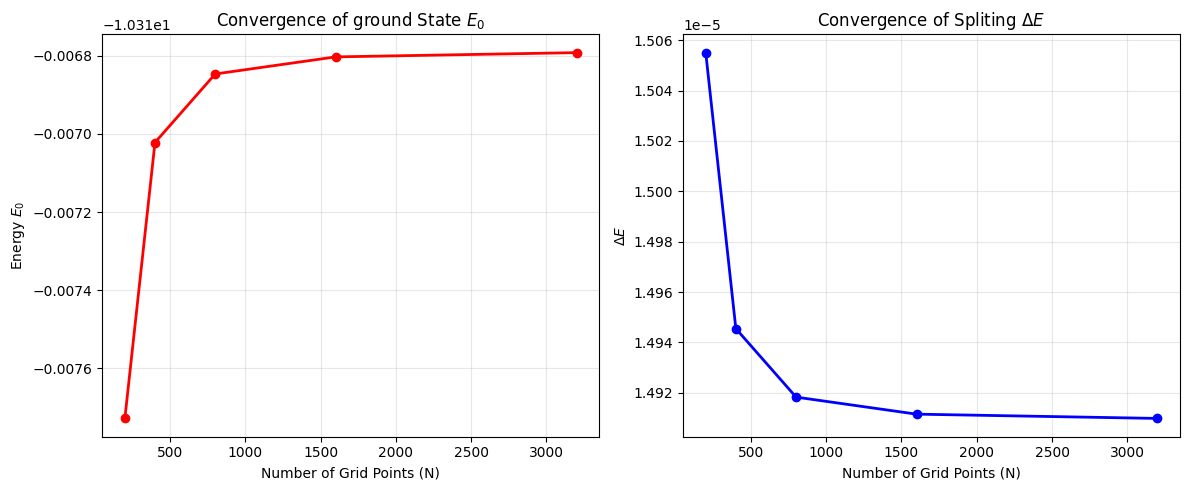

In [15]:
def potential(x):
    return -0.5*alpha*x**2 + beta*x**4
results = []

for N in [200,400,800,1600,3200]:
    x=np.linspace(-L,L,N)
    dx = x[1]-x[0]
    V = potential(x)
    main = np.full(N,2.0)
    off  = np.full(N-1,-1.0)

    laplacian = sp.diags(
        [off, main, off],
        [-1,0,1]
    )/dx**2

    T = (h_bar**2/(2*m))*laplacian
    H = T + sp.diags(V)
    eigvals, eigvecs = eigsh(H, k=2,which='SA')
    eigvals = np.sort(eigvals)
    E_0 = eigvals[0]
    E_1 = eigvals[1]

    results.append([N,E_0,E_1,E_1-E_0])

df = pd.DataFrame(
    results,
    columns = ["N","E0","E1","Delta E"]
)
print(df)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(df["N"],df["E0"], 'ro-', lw=2)
plt.title("Convergence of ground State $E_0$")
plt.xlabel("Number of Grid Points (N)")
plt.ylabel("Energy $E_0$")
plt.grid(alpha=0.3)

#ploting the enrgy splitting (Delta E) vs N
plt.subplot(1,2,2)
plt.plot(df["N"],df["Delta E"], 'bo-', lw=2)
plt.title("Convergence of Spliting $\Delta E$")
plt.xlabel("Number of Grid Points (N)")
plt.ylabel("$\Delta E$")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Conclusion & Final Answers

Through the Finite Difference Method, we successfully diagonalized the Hamiltonian and obtained the following physical results for the Quartic Double Well:

### 1. Energy Eigenvalues
The particle is deeply trapped inside the wells, far below the central barrier ($V=0$):
*   **Ground State ($E_0$):** $\approx -10.3168$
*   **First Excited State ($E_1$):** $\approx -10.3168$

### 2. Energy Splitting
Quantum tunneling breaks the exact degeneracy of the left and right wells, resulting in a microscopic energy gap between the symmetric and anti-symmetric states:
*   **$\Delta E = E_1 - E_0$:** $\approx 1.492 \times 10^{-5}$

### 3. Tunneling Time
Using Natural Units ($\hbar = 1$):
*   **Full Tunneling Period ($T$):** $\approx 421,264.7$
*   **Tunneling Time ($\tau$):** $\approx 210,632.3$
*(The tunneling time $\tau$ required for a particle to travel from the right well to the left well is exactly half of a full oscillation period: $\tau = T/2 = \pi/\Delta E$)*.

### Final Verification
Our **Grid Convergence Study** demonstrated that our calculation for the highly sensitive value of $\Delta E$ is stable. As the number of grid points $N$ increased, the values asymptotically flattened out, proving our numerical results accurately reflect the continuous physics of the Schrödinger Equation!
